Dataset Shape: (28813, 19)
   Invoice Product_ID                          Description  Quantity  \
0   536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1   536365      71053                  WHITE METAL LANTERN         6   
2   536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3   536365     84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4   536365     84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          Invoice_Date  Price  Customer_ID         Country    Year  Month  \
0  2010-12-01 08:26:00   2.55        17850  United Kingdom  2010.0   12.0   
1  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010.0   12.0   
2  2010-12-01 08:26:00   2.75        17850  United Kingdom  2010.0   12.0   
3  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010.0   12.0   
4  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010.0   12.0   

   Day  DayOfWeek  Total_Amount  Recency  Frequency  Monetary  Churn  Segment

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:38:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Model Accuracy: 100.0


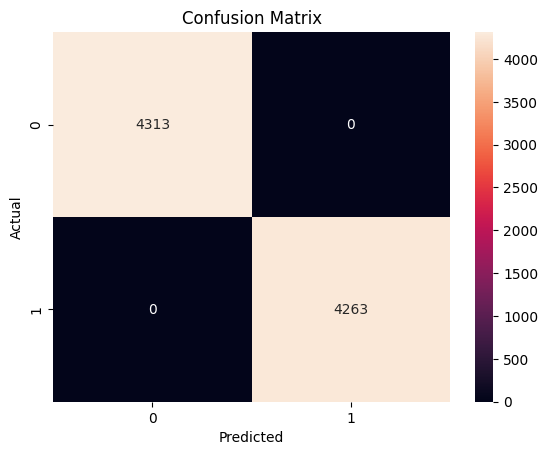

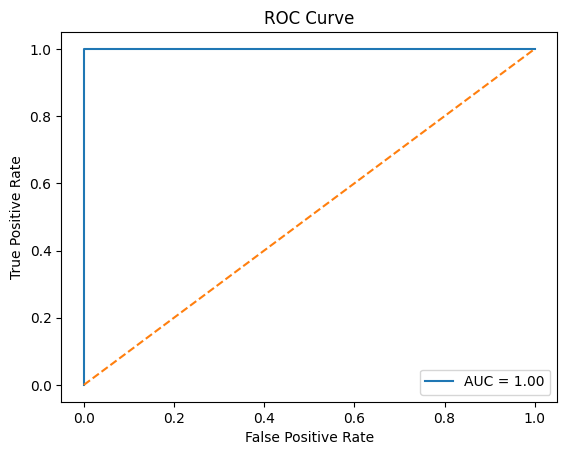

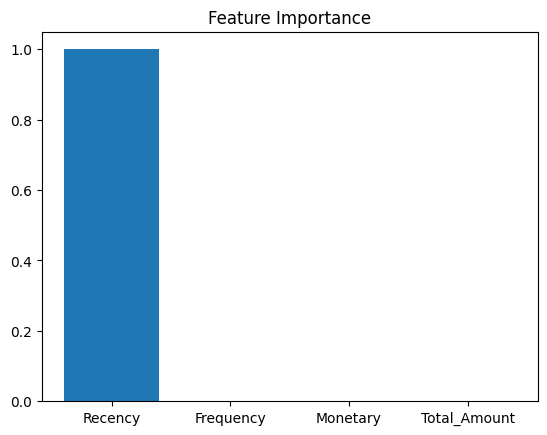


✅ Model and Scaler saved successfully!

Sample Prediction: Not Churn


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:

# 🔹 STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from xgboost import XGBClassifier

# 🔹 STEP 2: LOAD DATA

df = pd.read_csv("cleaned_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# 🔹 STEP 3: SELECT FEATURES

features = ['Recency', 'Frequency', 'Monetary', 'Total_Amount']
target = 'Churn'

X = df[features]
y = df[target]

# 🔹 STEP 4: HANDLE CLASS IMBALANCE

df_majority = df[df.Churn == 0]
df_minority = df[df.Churn == 1]

print("Before Balancing:")
print(df['Churn'].value_counts())

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("\nAfter Balancing:")
print(df_balanced['Churn'].value_counts())

# Update X and y
X = df_balanced[features]
y = df_balanced[target]

# 🔹 STEP 5: TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 STEP 6: FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 STEP 7: TRAIN MODEL

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

model.fit(X_train, y_train)

# 🔹 STEP 8: PREDICTIONS

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 🔹 STEP 9: ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("\n✅ Model Accuracy:", accuracy*100)

# 🔹 STEP 10: CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 STEP 11: ROC CURVE

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# 🔹 STEP 12: FEATURE IMPORTANCE

importance = model.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

# 🔹 STEP 13: SAVE MODEL

joblib.dump(model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model and Scaler saved successfully!")

# 🔹 STEP 14: TEST SAMPLE INPUT

sample = [[30, 5, 2000, 10000]]  # Example values

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("\nSample Prediction:", "Churn" if prediction[0] == 1 else "Not Churn")